In [26]:
!pip install -U ultralytics supervision

import ultralytics
ultralytics.checks()

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.9/112.6 GB disk)


In [67]:
import os
from google.colab import drive

os.chdir("/content")

In [11]:
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
dataset_location = "/content"
os.makedirs(dataset_location, exist_ok=True)

In [14]:
import zipfile

zip_file_path = "/content/drive/MyDrive//Purwadhika/Dataset Capstone 4/vehicle-detection.v1i.yolov12.zip"

if os.path.exists(zip_file_path):
    print("Mengekstrak dataset dari Google Drive ke /content/dataset_location...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_location)
    print(f"Dataset berhasil diekstrak ke: {dataset_location}")
else:
    print(f"File zip tidak ditemukan di {zip_file_path}. Periksa kembali path foldermu di Google Drive!")

Mengekstrak dataset dari Google Drive ke /content/dataset_location...
Dataset berhasil diekstrak ke: /content


In [16]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2026-09-15 12:35:55--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-15T13%3A15%3A29Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-15T12%3A14%3A51Z&ske=2026-09-15T13%3A15%3A29Z&sks=b&skv=2018-11-09&sig=DAgAI2riR%2FNwhWcCcyPtO%2Fy9YSF8B8L3Yr85raFR5Yg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTQ3NjA1NSwibmJmIjoxNzg5NDc1NzU1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG

In [17]:
from ultralytics import YOLO

model = YOLO('yolov12n.pt')

In [20]:
results = model.train(
    data=f"{dataset_location}/data.yaml",
    epochs=50,                          # Epoch Number
    imgsz=640,                          # Image Size Input
    batch=16,
    exist_ok=True,
    patience=5,                         # Early stopping if no improvement for 5 epochs
    save_period=5,                      # Save checkpoints every 5 epochs
    val=True,                           # Ensure validation is performed
    verbose=True,                       # Show detailed output during training
    flipud=0.5,
)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optim

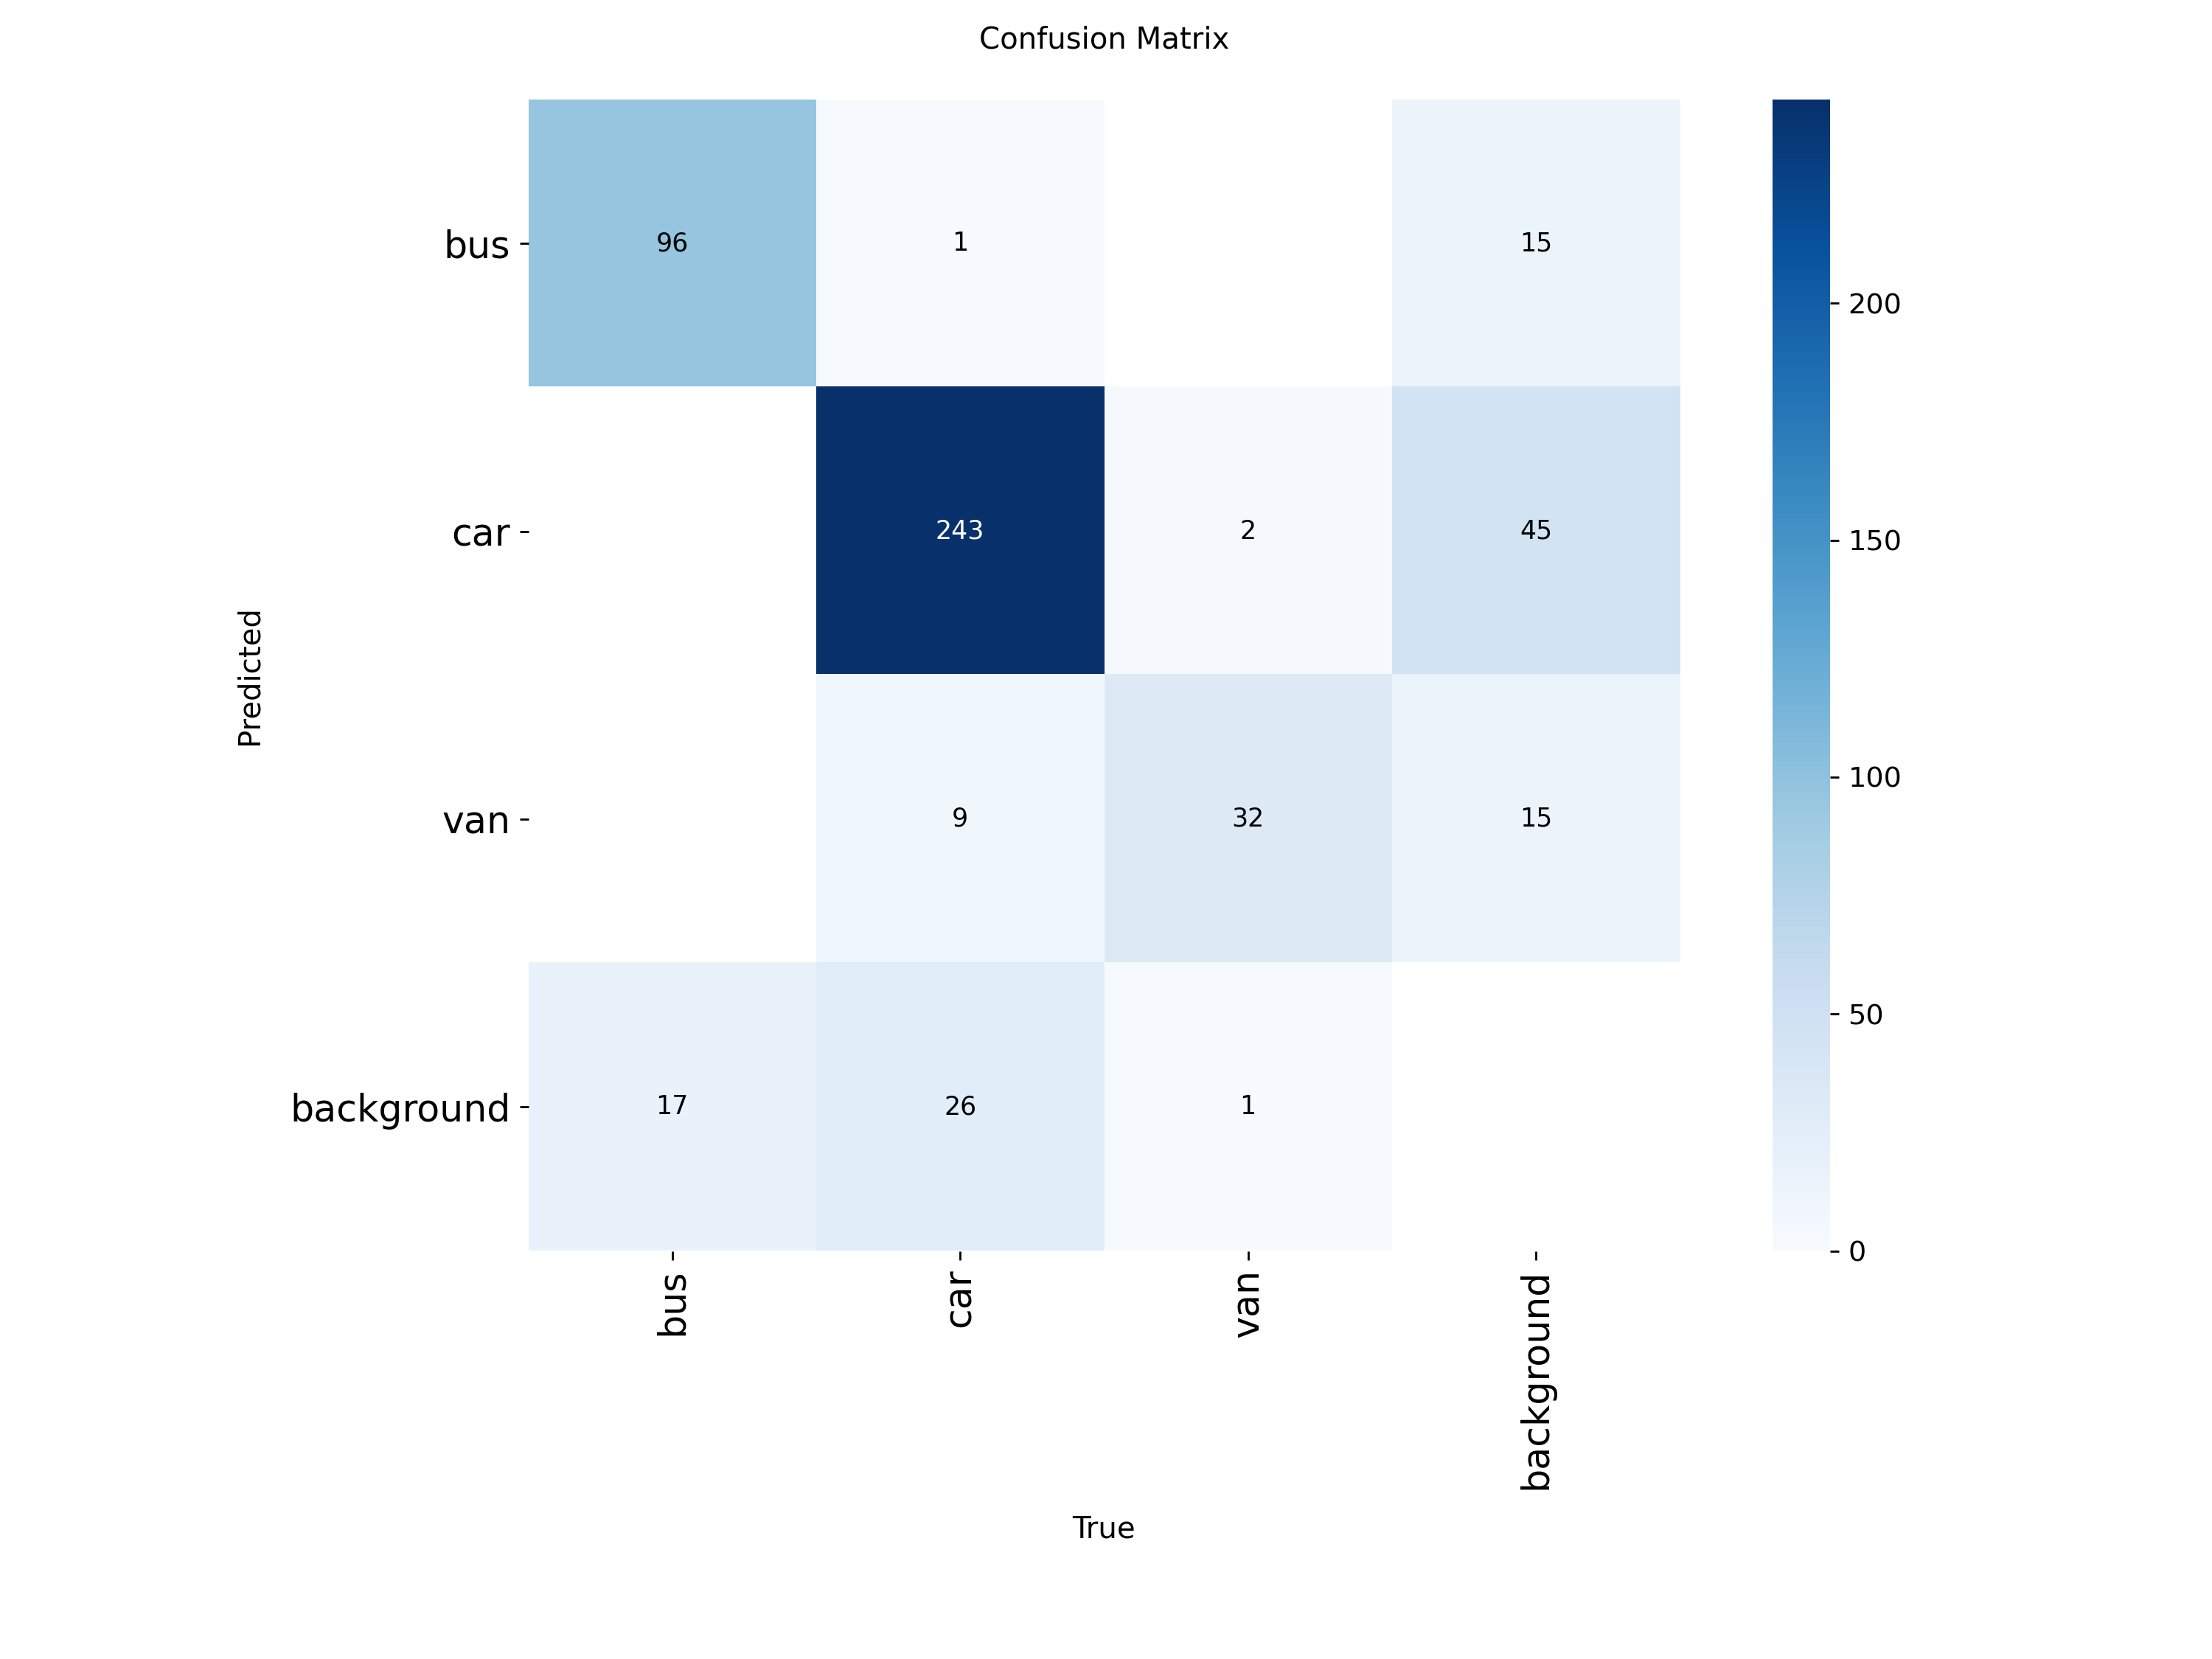

In [21]:
 from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

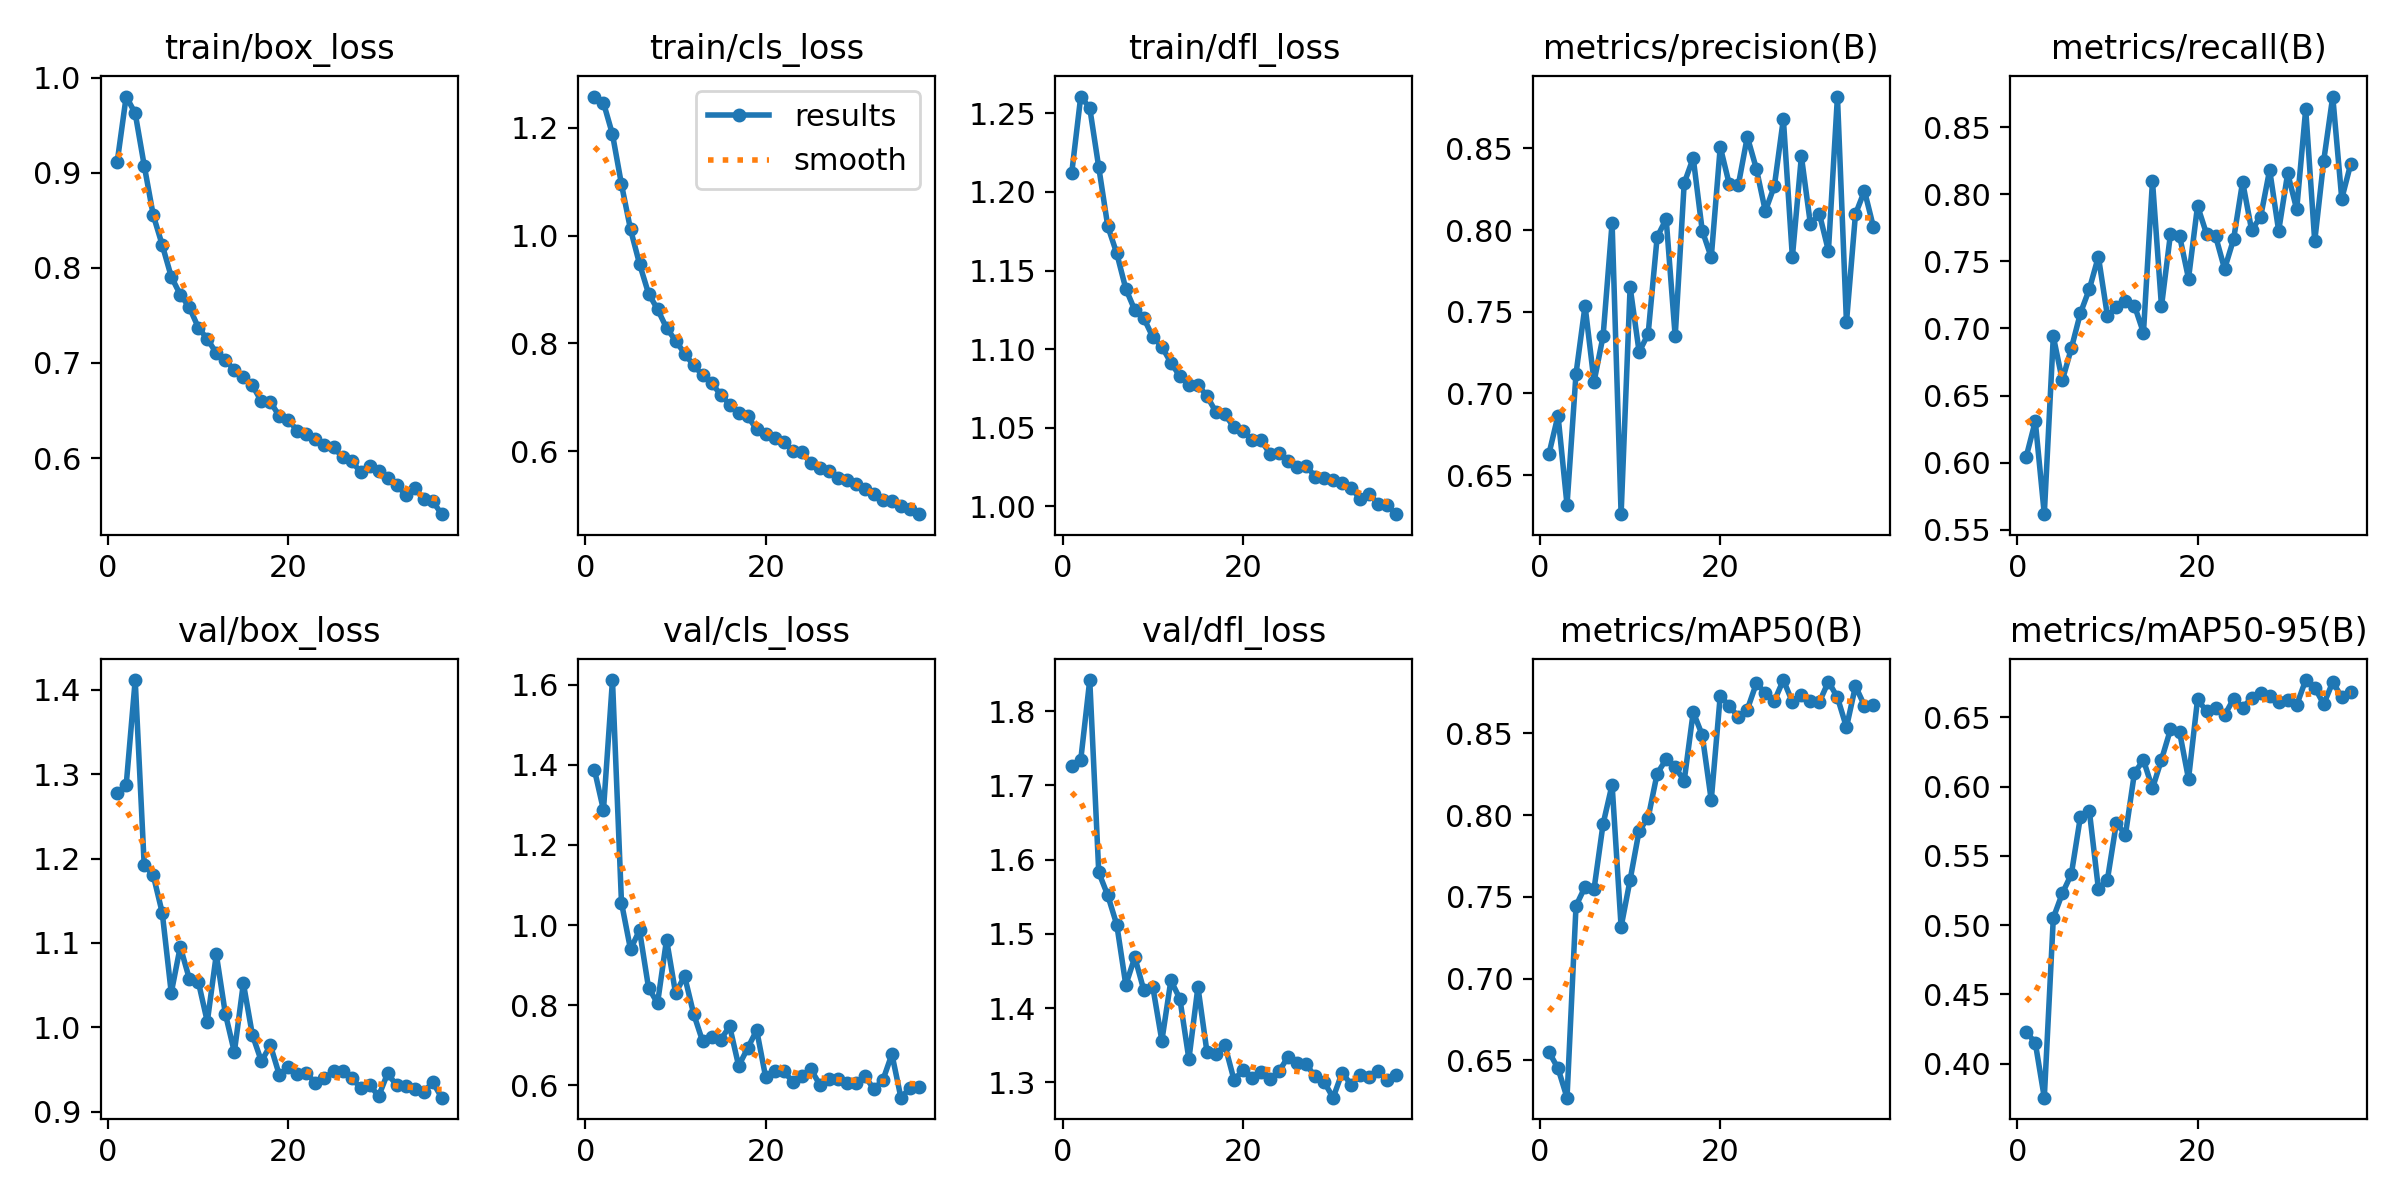

In [22]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

In [27]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

ds.classes

['bus', 'car', 'van']

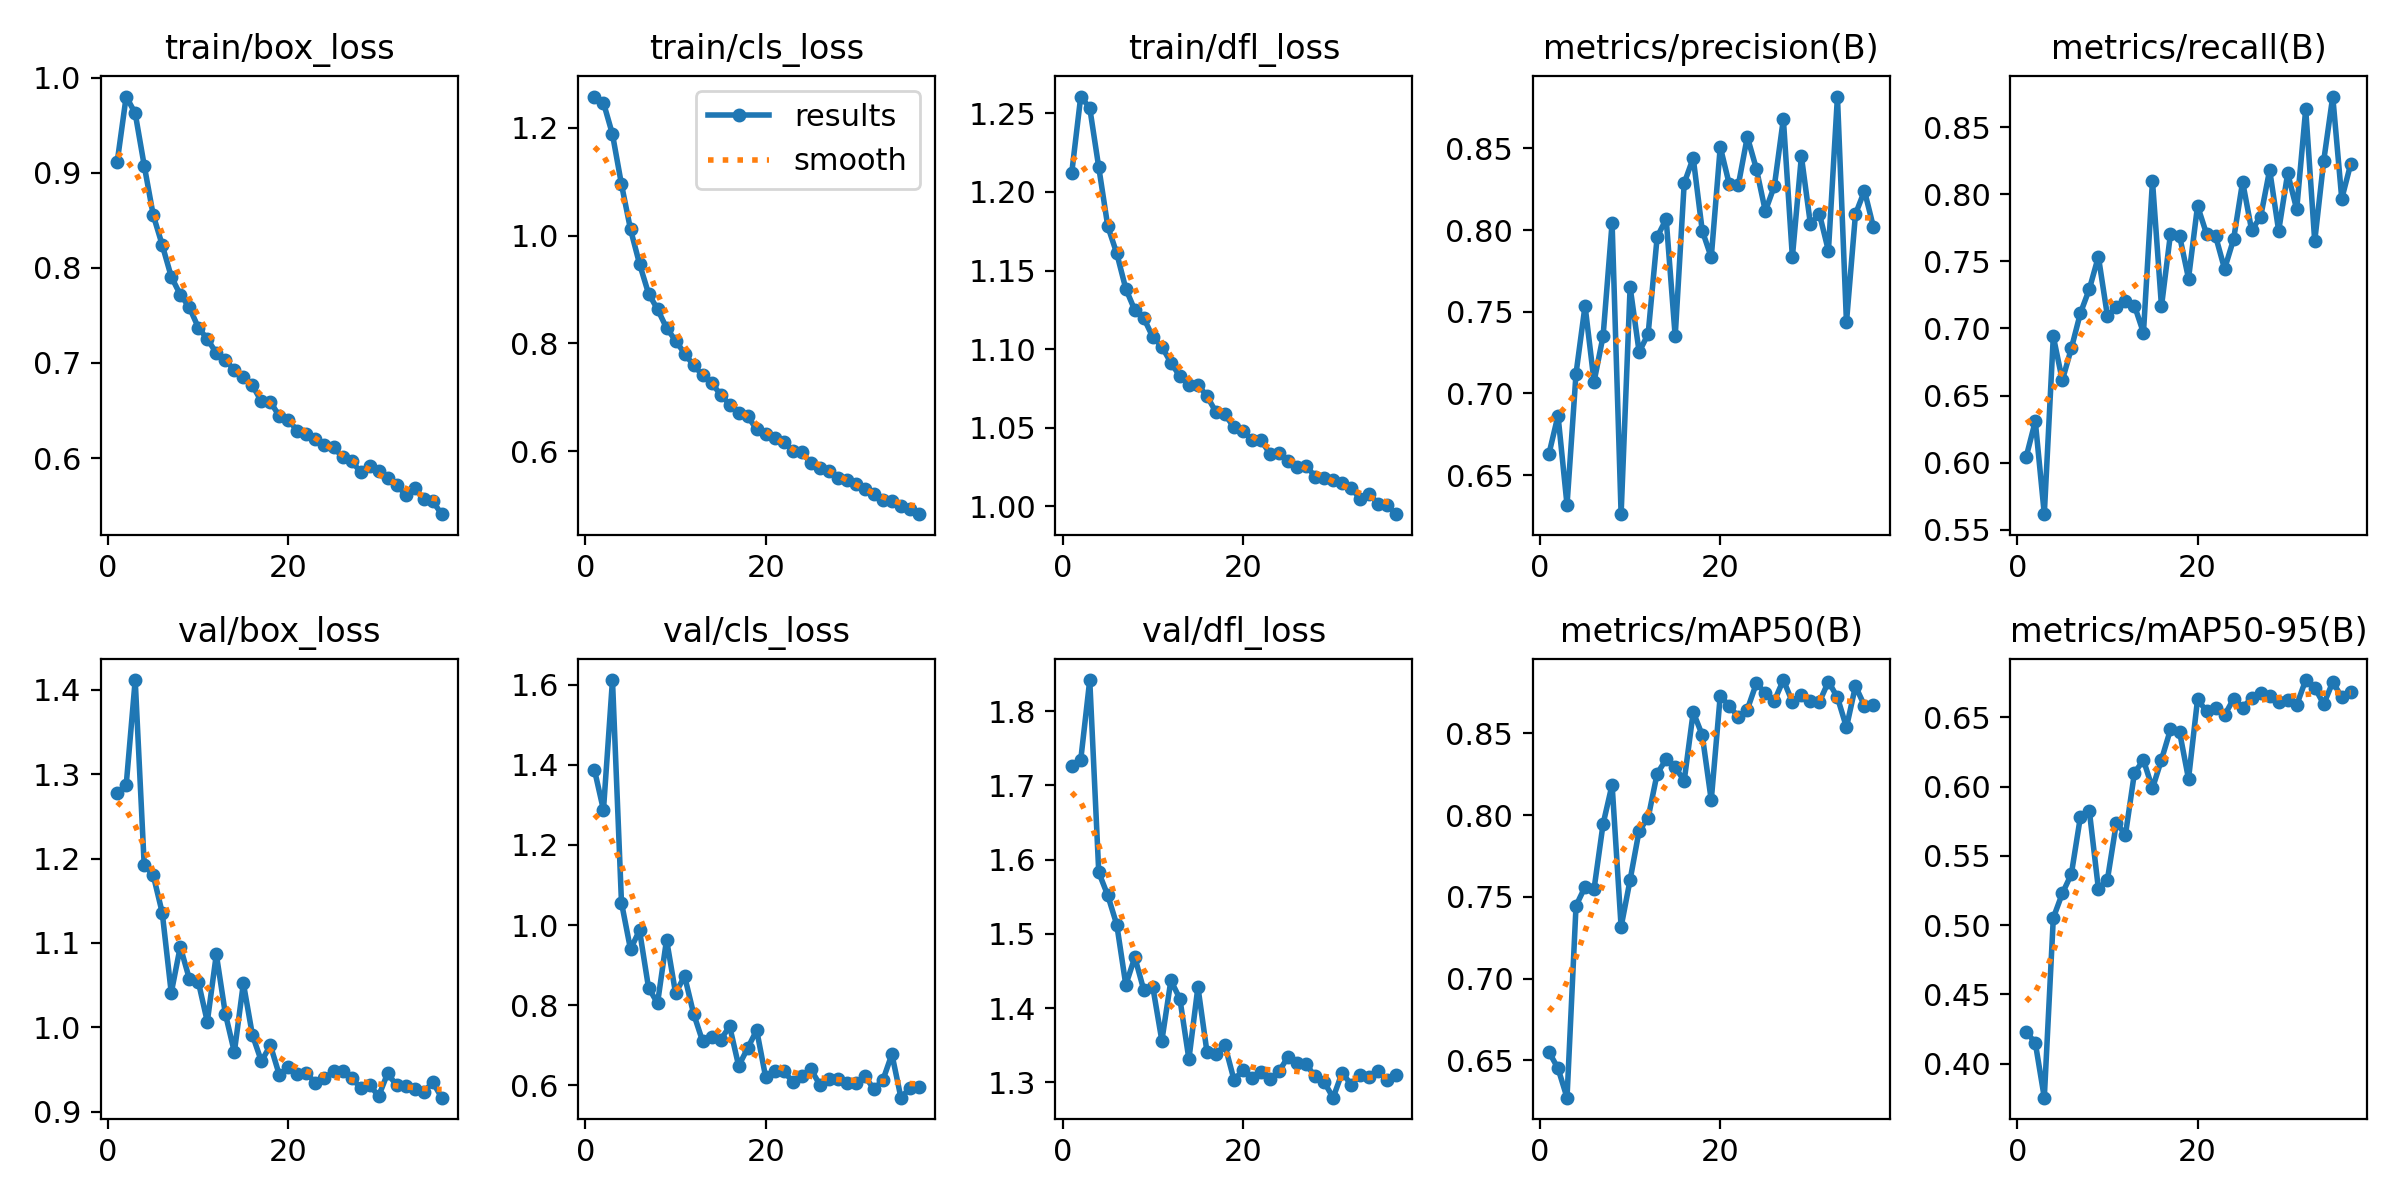

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2637.1±1330.4 MB/s, size: 95.3 KB)
val: Scanning /content/valid/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 63.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 19, len(boxes) = 427. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.7it/s 4.8s
                   all        287        427      0.788      0.864      0.883      0.676
                   bus         67        113      0.883       0.85      0.913      0.673
                   car        211        279   

In [30]:
import os
import matplotlib.pyplot as plt
from IPython.display import Image, display

results_img_path = "/content/runs/detect/train/results.png"

if os.path.exists(results_img_path):
    display(Image(filename=results_img_path, width=800))
else:
    print("Grafik results.png tidak ditemukan.")

metrics = model.val()
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

In [65]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

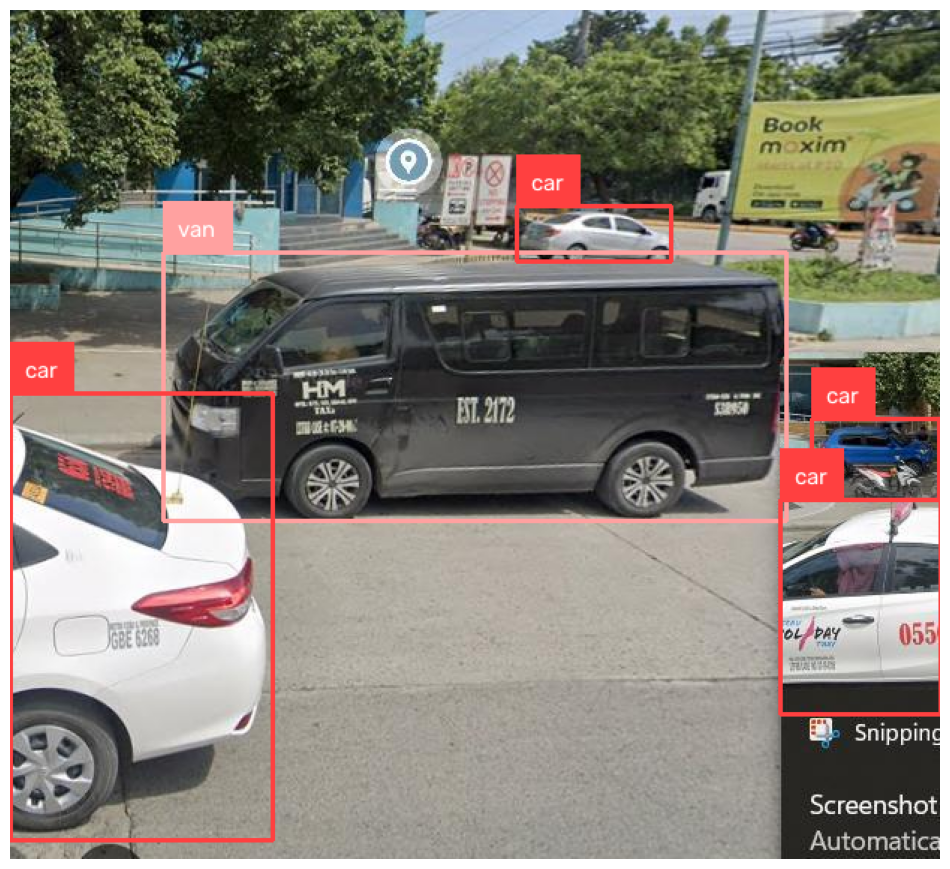

In [66]:
sv.plot_image(annotated_image)